## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

The air fryer market from 2019–2023 consists of 10 brands with market shares correctly normalized within each year, and it appears moderately stable over time with a few dominant players maintaining larger shares. Brands like Dash and GoWISE USA have relatively high market shares, while others like Cosori initially have very small presence. Prices vary substantially across brands, with some (e.g., Cuisinart) positioned as more premium, while others compete on lower prices. Average ratings are consistently high across brands, suggesting strong overall consumer satisfaction. In terms of product characteristics, compact designs are nearly universal, while features like dual baskets and rotisserie functions are relatively rare, indicating niche offerings. There is also evidence of specialization, with some brands focusing more on oven-style or feature-rich products, while others emphasize simpler, compact models.

In [1]:
import pandas as pd

df = pd.read_csv("air_fryers_clean_brand_year.csv")

print(df.shape)
print(df.head())
print(df.groupby("year")["brand_share"].sum())
print(df["brand"].nunique())
print(df["year"].unique())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

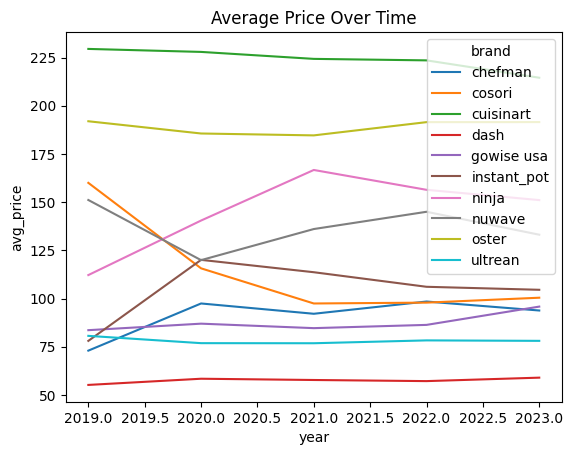

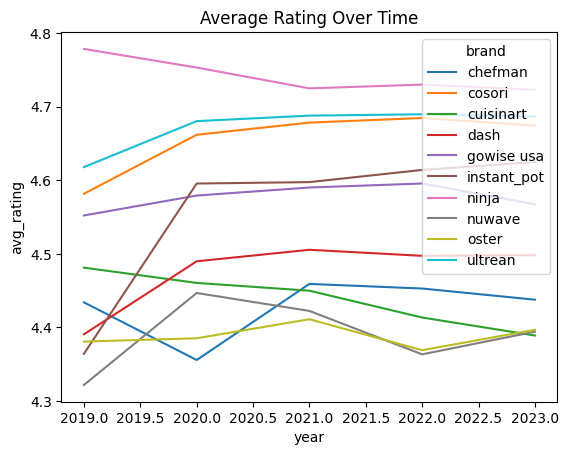

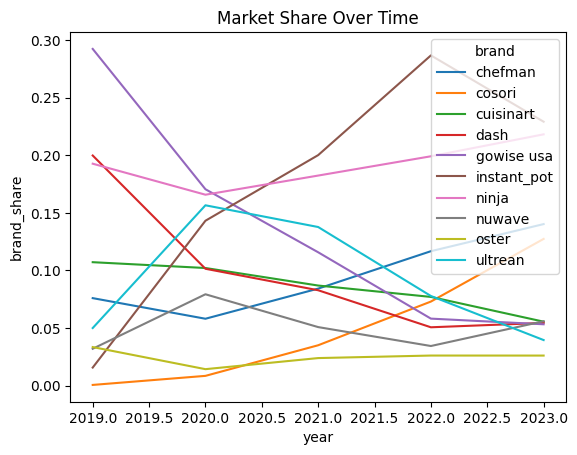

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="year", y="avg_price", hue="brand")
plt.title("Average Price Over Time")
plt.show()

sns.lineplot(data=df, x="year", y="avg_rating", hue="brand")
plt.title("Average Rating Over Time")
plt.show()

sns.lineplot(data=df, x="year", y="brand_share", hue="brand")
plt.title("Market Share Over Time")
plt.show()

In [3]:
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

df[feature_cols].mean().sort_values(ascending=False)
df.groupby("brand")[feature_cols].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000
